# Model comparison notebook

This notebook compares the final **Rejection ABC** and **SMC-ABC** posteriors for the adaptive-network epidemic model. It loads saved posterior samples, reconstructs the final posterior draws used for each method, visualizes marginal and pairwise posterior structure, runs posterior predictive checks, and computes quantitative comparison metrics such as **PPC error**, **trajectory RMSE**, and **absolute pairwise posterior correlations**.


## 1. Load saved posterior samples

This cell imports the required packages, sets plotting defaults, and loads the saved `.npz` result files for Rejection ABC and SMC-ABC. It then reconstructs the final posterior samples used in the comparison.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulator import simulate
from time import time
import csv, os


# Reproducibility
SEED = 42

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# Rejection ABC results
rej_data = np.load("rejection_abc_results.npz")

# Use the final summary-statistic subset
subset = 2
rej_params = rej_data[f"sub{subset}_params"]
rej_dists = rej_data[f"sub{subset}_dists"]
obs_summary = rej_data[f"obs_summary_sub{subset}"]
norm_mean = rej_data["norm_mean"][:len(obs_summary)]
norm_std = rej_data["norm_std"][:len(obs_summary)]

# Reconstruct accepted posterior for rejection ABC
accept_pct = 1.0   # same as your final rejection ABC setting
n_accept = max(1, int(len(rej_params) * accept_pct / 100))
accepted_idx = np.argsort(rej_dists)[:n_accept]
rej_posterior = rej_params[accepted_idx]

# SMC results
smc_data = np.load("smc_abc_results.npz")

rng = np.random.default_rng(SEED)

if "resampled_particles" in smc_data.files:
    smc_posterior = smc_data["resampled_particles"]
else:
    smc_particles = smc_data["particles"]
    smc_weights = smc_data["weights"]
    idx = rng.choice(len(smc_particles), size=5000, p=smc_weights, replace=True)
    smc_posterior = smc_particles[idx]

## 2. Plot combined marginal histograms

This cell defines a helper to compute common density limits and plots the marginal posterior histograms for the two methods on the same figure, using matched axis scales for direct comparison.


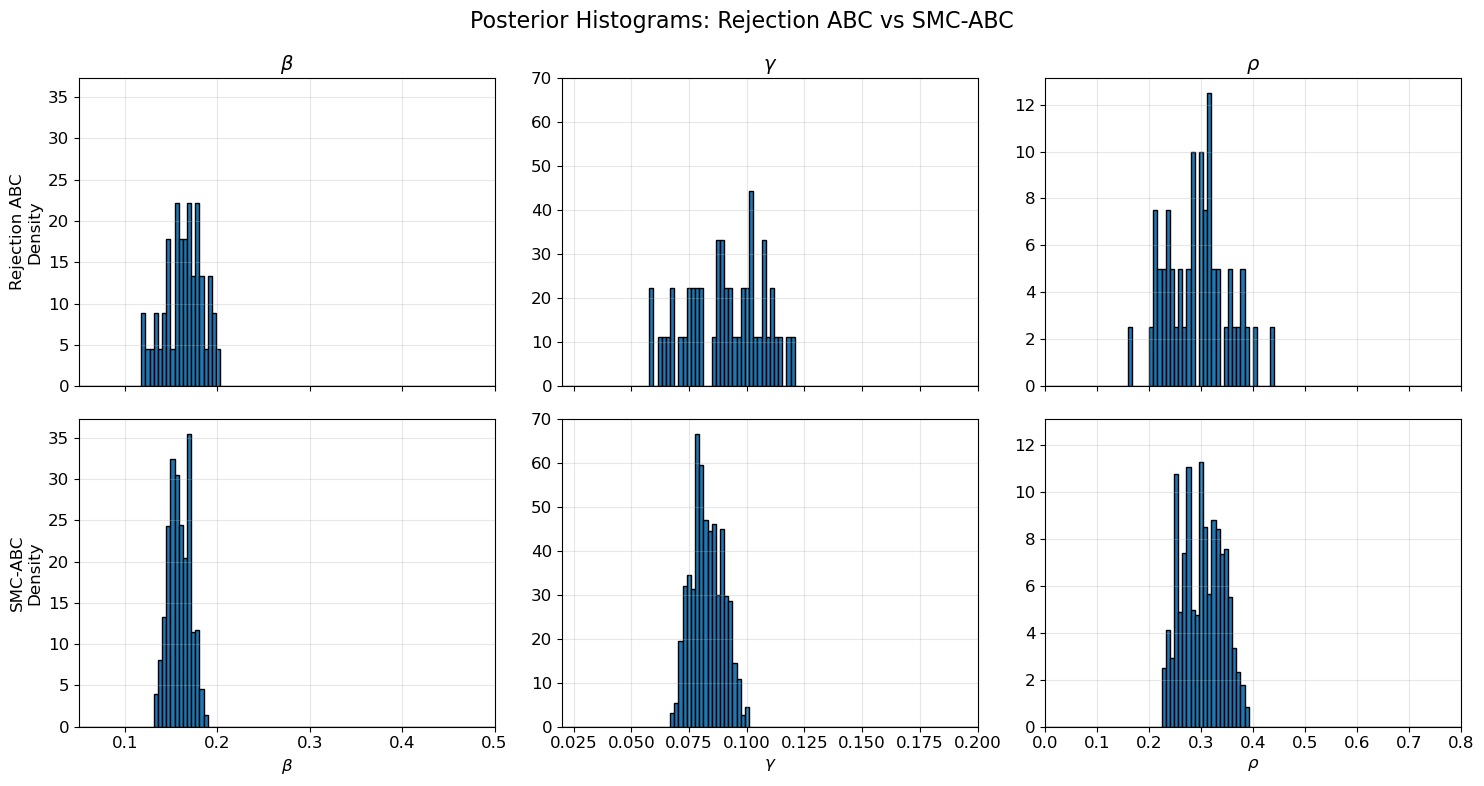

In [2]:
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.0, 0.80)]

def get_density_limits(sample_list, bins=100):
    ymax = [0, 0, 0]
    for samples in sample_list:
        for j in range(3):
            lo, hi = PRIOR_BOUNDS[j]
            edges = np.linspace(lo, hi, bins + 1)
            hist, _ = np.histogram(samples[:, j], bins=edges, density=True)
            ymax[j] = max(ymax[j], hist.max())
    return ymax

def plot_combined_histograms(rej_posterior, smc_posterior, bins=100):
    sample_list = [rej_posterior, smc_posterior]
    row_titles = ["Rejection ABC", "SMC-ABC"]
    common_ymax = get_density_limits(sample_list, bins=bins)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex='col')

    for i, samples in enumerate(sample_list):
        for j in range(3):
            ax = axes[i, j]
            lo, hi = PRIOR_BOUNDS[j]
            edges = np.linspace(lo, hi, bins + 1)

            ax.hist(samples[:, j], bins=edges, density=True, edgecolor="black")
            ax.set_xlim(lo, hi)
            ax.set_ylim(0, common_ymax[j] * 1.05)

            if i == 0:
                ax.set_title(PARAM_NAMES[j], fontsize=14)

            if i == 1:
                ax.set_xlabel(PARAM_NAMES[j], fontsize=12)

            if j == 0:
                ax.set_ylabel(f"{row_titles[i]}\nDensity", fontsize=12)

    fig.suptitle("Posterior Histograms: Rejection ABC vs SMC-ABC", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

plot_combined_histograms(rej_posterior, smc_posterior, bins=100)

## 3. Load the observed dataset

This cell reads the observed infection trajectories, rewiring counts, and final degree histograms from CSV files, then prints a quick summary of the loaded data.


In [3]:
def load_observed_data(data_dir="data"):
    """Load the three observed CSV data files.
    
    Returns
    -------
    infected : dict, replicate_id -> np.array of shape (201,)
    rewiring : dict, replicate_id -> np.array of shape (201,)
    degree   : dict, replicate_id -> np.array of shape (31,)
    """
    
    def read_csv(path):
        with open(path) as f:
            return list(csv.DictReader(f))
    
    # Infected time series
    rows = read_csv(os.path.join(data_dir, "infected_timeseries.csv"))
    infected = {}
    for row in rows:
        rid, t = int(row["replicate_id"]), int(row["time"])
        if rid not in infected:
            infected[rid] = np.zeros(201)
        infected[rid][t] = float(row["infected_fraction"])
    
    # Rewiring time series
    rows = read_csv(os.path.join(data_dir, "rewiring_timeseries.csv"))
    rewiring = {}
    for row in rows:
        rid, t = int(row["replicate_id"]), int(row["time"])
        if rid not in rewiring:
            rewiring[rid] = np.zeros(201)
        rewiring[rid][t] = int(row["rewire_count"])
    
    # Final degree histograms
    rows = read_csv(os.path.join(data_dir, "final_degree_histograms.csv"))
    degree = {}
    for row in rows:
        rid, d = int(row["replicate_id"]), int(row["degree"])
        if rid not in degree:
            degree[rid] = np.zeros(31)
        degree[rid][d] = int(row["count"])
    
    return infected, rewiring, degree


obs_infected, obs_rewiring, obs_degree = load_observed_data("data")

N_REPLICATES = len(obs_infected)
print(f"Loaded {N_REPLICATES} replicates")
print(f"Infection series shape: {obs_infected[0].shape}")
print(f"Rewiring series shape:  {obs_rewiring[0].shape}")
print(f"Degree histogram shape: {obs_degree[0].shape}")


Loaded 40 replicates
Infection series shape: (201,)
Rewiring series shape:  (201,)
Degree histogram shape: (31,)


## 4. Define plotting and summary helpers

This cell defines reusable functions for plotting marginal posteriors, pairwise posterior scatter plots, posterior predictive checks, and printed posterior summaries.


In [4]:
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.0, 0.80)]


def plot_marginals(accepted_params, title=""):
    """Plot marginal posterior histograms for each parameter."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for i, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
        samples = accepted_params[:, i]

        ax.hist(
            samples,
            bins=30,
            density=True,
            alpha=0.9,
            color="steelblue",
            edgecolor="white",
            label="Posterior",
        )

        prior_height = 1.0 / (bounds[1] - bounds[0])
        ax.axhline(
            prior_height,
            color="gray",
            linestyle="--",
            alpha=0.7,
            label="Prior",
        )

        ax.axvline(
            np.mean(samples),
            color="navy",
            linewidth=1.5,
            linestyle=":",
            label=f"Mean={np.mean(samples):.3f}",
        )

        ax.set_xlabel(name, fontsize=14)
        ax.set_ylabel("Density" if i == 0 else "")
        ax.set_xlim(bounds)
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_pairwise(accepted_params, title=""):
    """Plot pairwise scatter plots of accepted parameters."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    pairs = [(0, 1), (0, 2), (1, 2)]

    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(
            accepted_params[:, i],
            accepted_params[:, j],
            alpha=0.4,
            s=10,
            color="steelblue",
        )
        ax.set_xlabel(PARAM_NAMES[i], fontsize=13)
        ax.set_ylabel(PARAM_NAMES[j], fontsize=13)
        ax.set_xlim(PRIOR_BOUNDS[i])
        ax.set_ylim(PRIOR_BOUNDS[j])

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_posterior_predictive(accepted_params, obs_infected, n_ppc=20, seed=777):
    """Simulate posterior predictive trajectories and overlay them on the observed data."""
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=(10, 5))

    for rid in sorted(obs_infected.keys()):
        ax.plot(obs_infected[rid], color="gray", alpha=0.15, linewidth=0.5)
    ax.plot([], [], color="gray", alpha=0.5, label="Observed")

    idx = rng.choice(len(accepted_params), size=n_ppc, replace=True)
    for k in idx:
        beta, gamma, rho = accepted_params[k]
        inf, _, _ = simulate(beta, gamma, rho, rng=rng)
        ax.plot(inf, color="steelblue", alpha=0.2, linewidth=0.5)
    ax.plot([], [], color="steelblue", alpha=0.6, label="Posterior predictive")

    ax.set_xlabel("Time step")
    ax.set_ylabel("Infected fraction")
    ax.set_title("Posterior Predictive Check")
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_posterior_summary(accepted_params):
    """Print posterior mean, median, and 95% credible interval for each parameter."""
    print(f"{'Parameter':>10s}  {'Mean':>8s}  {'Median':>8s}  {'95% CI':>15s}")
    print("-" * 55)

    for i, name in enumerate(PARAM_NAMES):
        samples = accepted_params[:, i]
        lo, hi = np.percentile(samples, [2.5, 97.5])
        print(
            f"{name:>10s}  {np.mean(samples):8.4f}  "
            f"{np.median(samples):8.4f}  [{lo:.4f}, {hi:.4f}]"
        )


## 5. Plot posterior predictive checks

This cell draws posterior predictive checks for Rejection ABC and SMC-ABC by simulating epidemic trajectories from posterior samples and overlaying them on the observed trajectories.


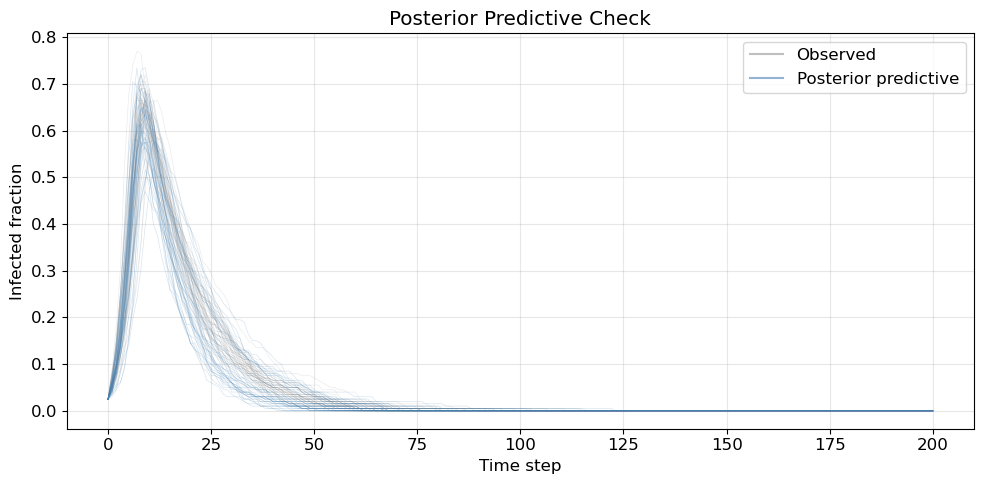

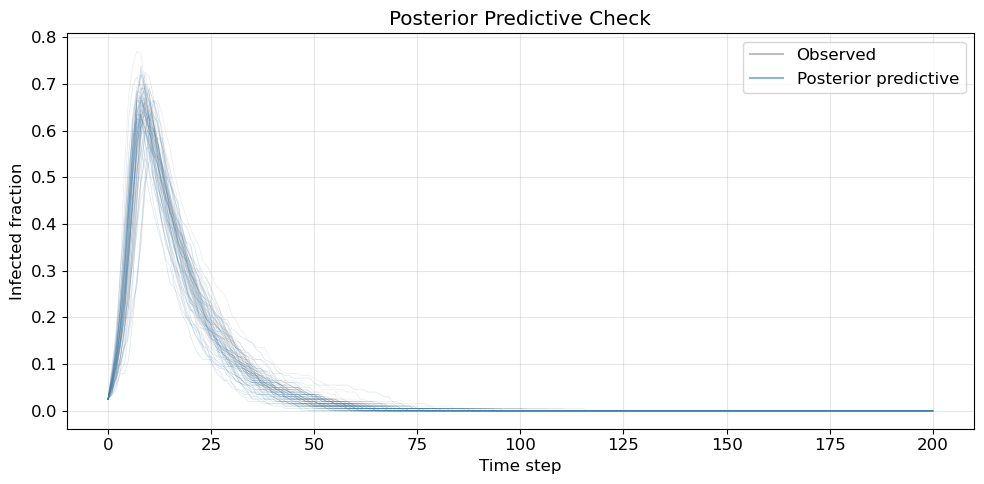

In [5]:
plot_posterior_predictive(rej_posterior, obs_infected, n_ppc=40)
plot_posterior_predictive(smc_posterior, obs_infected, n_ppc=40)


## 6. Define predictive-fit helper functions

This cell defines helper functions to simulate from posterior samples, compute posterior predictive errors, and calculate the RMSE between predicted and observed mean infection trajectories.


In [6]:
def simulate_from_posterior_samples(
    posterior_samples,
    subset,
    obs_summary,
    norm_mean,
    norm_std,
    n_draws=40,
    n_reps_per_draw=40,
    distance_name="euclidean",
    seed=42
):
    """
    For each posterior draw:
      - sample one theta from posterior_samples
      - simulate n_reps_per_draw epidemics
      - compute averaged summary stats
      - compute normalized distance to observed summary
      - store the mean infection trajectory across reps
    Returns:
      ppc_errors: shape (n_draws,)
      mean_trajs: shape (n_draws, T)
    """
    rng = np.random.default_rng(seed)
    dist_fn = DISTANCE_FUNCTIONS[distance_name]

    ppc_errors = []
    mean_trajs = []

    for _ in range(n_draws):
        theta = posterior_samples[rng.integers(len(posterior_samples))]

        inf_dict, rew_dict, deg_dict = {}, {}, {}
        for r in range(n_reps_per_draw):
            inf, rew, deg = simulate(*theta, rng=rng)
            inf_dict[r] = np.asarray(inf)
            rew_dict[r] = rew
            deg_dict[r] = deg

        sim_summary = compute_summaries_averaged(
            inf_dict, rew_dict, deg_dict, subset=subset
        )
        dist = dist_fn(sim_summary, obs_summary, norm_mean, norm_std)
        ppc_errors.append(dist)

        traj_mat = np.stack([inf_dict[r] for r in range(n_reps_per_draw)], axis=0)
        mean_trajs.append(traj_mat.mean(axis=0))

    return np.array(ppc_errors), np.array(mean_trajs)


def compute_observed_mean_trajectory(obs_infected):
    """
    obs_infected can be:
      - dict of trajectories
      - list of trajectories
      - 2D array (n_obs, T)
    Returns mean observed trajectory of shape (T,)
    """
    if isinstance(obs_infected, dict):
        obs_mat = np.stack([np.asarray(v) for v in obs_infected.values()], axis=0)
    else:
        obs_mat = np.stack([np.asarray(v) for v in obs_infected], axis=0)
    return obs_mat.mean(axis=0)


def trajectory_rmse(pred_mean_trajs, obs_infected):
    """
    pred_mean_trajs: shape (n_draws, T), from posterior predictive simulations
    obs_infected: observed trajectories
    Returns RMSE between posterior predictive mean curve and observed mean curve
    """
    pred_curve = pred_mean_trajs.mean(axis=0)
    obs_curve = compute_observed_mean_trajectory(obs_infected)
    return np.sqrt(np.mean((pred_curve - obs_curve) ** 2))

## 7. Define normalized distance functions

This cell defines the normalized Euclidean and Manhattan distances used when comparing simulated and observed summary statistics.


In [7]:
def distance_euclidean(s_sim, s_obs, norm_mean, norm_std):
    """Normalized Euclidean (L2) distance."""
    z_sim = (s_sim - norm_mean) / norm_std
    z_obs = (s_obs - norm_mean) / norm_std
    return np.sqrt(np.sum((z_sim - z_obs)**2))


def distance_manhattan(s_sim, s_obs, norm_mean, norm_std):
    """Normalized Manhattan (L1) distance."""
    z_sim = (s_sim - norm_mean) / norm_std
    z_obs = (s_obs - norm_mean) / norm_std
    return np.sum(np.abs(z_sim - z_obs))


DISTANCE_FUNCTIONS = {
    "euclidean": distance_euclidean,
    "manhattan": distance_manhattan,
}

## 8. Define summary-statistic functions

This cell defines the summary statistics used in the analysis, including functions for computing summaries from a single replicate and averaging them across replicates.


In [8]:
def compute_summaries_single(infected_curve, rewiring_curve, degree_histogram, subset=3):
    """Compute summary statistics from a single replicate."""
    stats = []

    # Subset 1: epidemic summaries
    peak_frac = np.max(infected_curve)
    stats.append(peak_frac)

    time_to_peak = np.argmax(infected_curve)
    stats.append(time_to_peak)

    if peak_frac > 0:
        post_peak = infected_curve[time_to_peak:]
        below_half = np.where(post_peak < peak_frac / 2)[0]
        half_life = below_half[0] if len(below_half) > 0 else len(post_peak)
    else:
        half_life = 0
    stats.append(half_life)

    if subset >= 2:
        # Subset 2: rewiring summaries
        peak_rewire = np.max(rewiring_curve)
        stats.append(peak_rewire)

        time_to_peak_rewire = np.argmax(rewiring_curve)
        stats.append(time_to_peak_rewire)

    if subset >= 3:
        # Subset 3: network-structure summary
        degrees = np.arange(31)
        total_nodes = np.sum(degree_histogram)
        if total_nodes > 0:
            mean_deg = np.dot(degrees, degree_histogram) / total_nodes
            var_deg = np.dot((degrees - mean_deg) ** 2, degree_histogram) / total_nodes
        else:
            var_deg = 0.0
        stats.append(var_deg)

    return np.array(stats, dtype=np.float64)


def compute_summaries_averaged(infected_dict, rewiring_dict, degree_dict, subset=3):
    """Compute summary statistics averaged across replicates."""
    all_stats = []
    for rid in sorted(infected_dict.keys()):
        s = compute_summaries_single(
            infected_dict[rid], rewiring_dict[rid], degree_dict[rid], subset=subset
        )
        all_stats.append(s)
    return np.mean(all_stats, axis=0)


SUMMARY_LABELS = {
    1: ["Peak fraction", "Time to peak", "Half-life"],
    2: ["Peak fraction", "Time to peak", "Half-life",
        "Peak rewire count", "Rewire time to peak"],
    3: ["Peak fraction", "Time to peak", "Half-life",
        "Peak rewire count", "Rewire time to peak", "Degree variance"],
}


## 9. Compute PPC error and trajectory RMSE

This cell computes posterior predictive errors and trajectory RMSE for both Rejection ABC and SMC-ABC, then prints the resulting comparison metrics.


In [9]:
rej_ppc_errors, rej_mean_trajs = simulate_from_posterior_samples(
    rej_posterior,
    subset=subset,
    obs_summary=obs_summary,
    norm_mean=norm_mean,
    norm_std=norm_std,
    n_draws=40,
    n_reps_per_draw=40,
    distance_name="euclidean",
    seed=42
)

smc_ppc_errors, smc_mean_trajs = simulate_from_posterior_samples(
    smc_posterior,
    subset=subset,
    obs_summary=obs_summary,
    norm_mean=norm_mean,
    norm_std=norm_std,
    n_draws=40,
    n_reps_per_draw=40,
    distance_name="euclidean",
    seed=42
)

rej_ppc_mean = rej_ppc_errors.mean()
smc_ppc_mean = smc_ppc_errors.mean()

rej_rmse = trajectory_rmse(rej_mean_trajs, obs_infected)
smc_rmse = trajectory_rmse(smc_mean_trajs, obs_infected)

print("Rejection ABC")
print(f"  Mean PPC error: {rej_ppc_mean:.4f}")
print(f"  Trajectory RMSE: {rej_rmse:.4f}")

print("\nSMC-ABC")
print(f"  Mean PPC error: {smc_ppc_mean:.4f}")
print(f"  Trajectory RMSE: {smc_rmse:.4f}")

Rejection ABC
  Mean PPC error: 0.5349
  Trajectory RMSE: 0.0137

SMC-ABC
  Mean PPC error: 0.2940
  Trajectory RMSE: 0.0028


## 10. Create a predictive-fit comparison table

This cell stores the PPC error and RMSE results in a small pandas table for easier inspection and export.


In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Rejection ABC", "SMC-ABC"],
    "Mean PPC error": [rej_ppc_mean, smc_ppc_mean],
    "Trajectory RMSE": [rej_rmse, smc_rmse]
})

comparison

,Model,Mean PPC error,Trajectory RMSE
0,Rejection ABC,0.534901,0.013748
1,SMC-ABC,0.293986,0.002825


## 11. Plot combined pairwise posterior comparisons

This cell plots the pairwise posterior relationships for Rejection ABC and SMC-ABC in a single combined figure with matched axis limits.


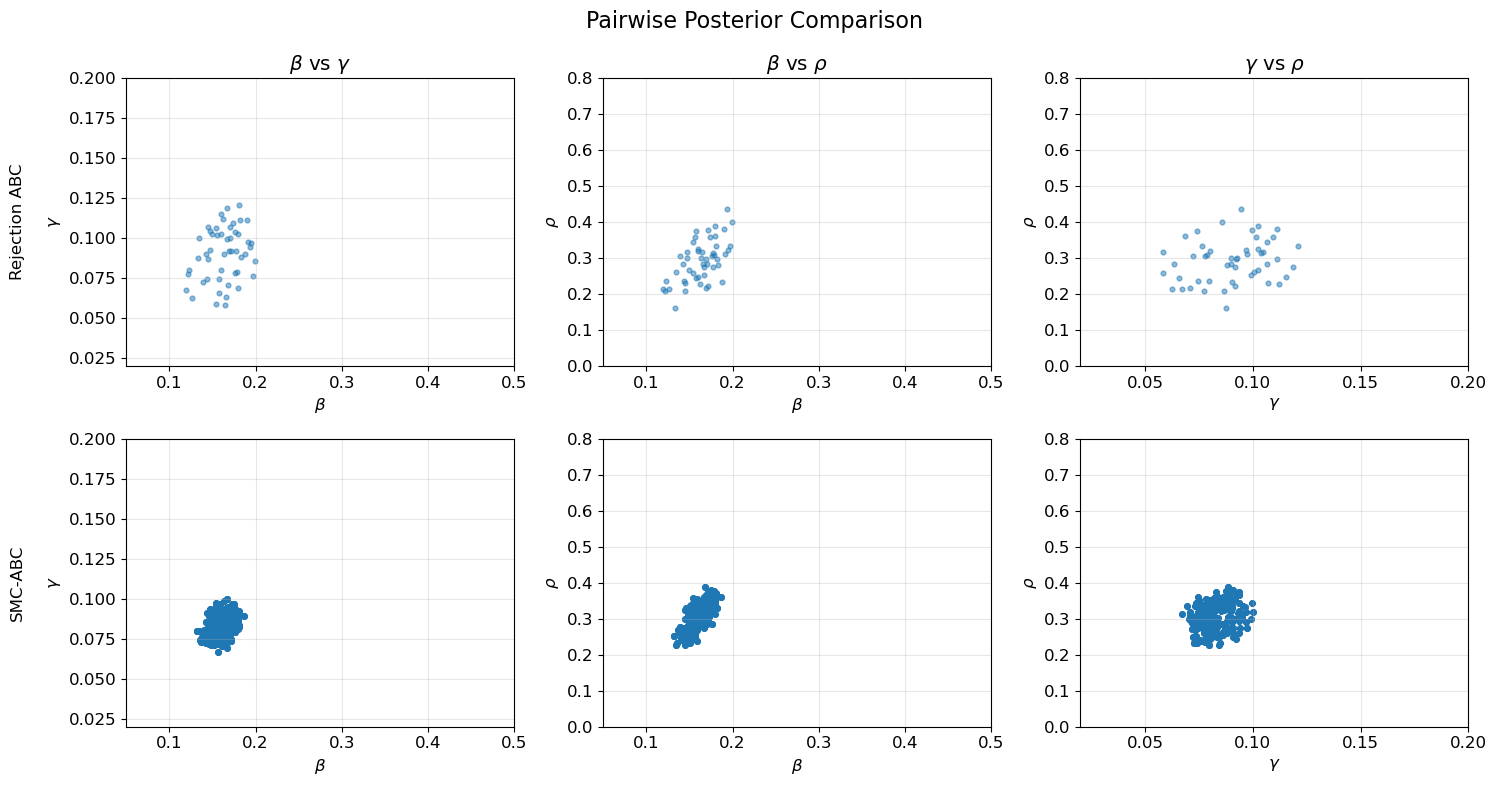

In [11]:
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.0, 0.80)]

def pairwise_scatter_combined(rej_posterior, smc_posterior):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    pairs = [(0, 1), (0, 2), (1, 2)]
    all_samples = [rej_posterior, smc_posterior]
    row_titles = ["Rejection ABC", "SMC-ABC"]

    for r, samples in enumerate(all_samples):
        for c, (i, j) in enumerate(pairs):
            ax = axes[r, c]
            ax.scatter(samples[:, i], samples[:, j], alpha=0.5, s=12)
            ax.set_xlim(PRIOR_BOUNDS[i])
            ax.set_ylim(PRIOR_BOUNDS[j])
            ax.set_xlabel(PARAM_NAMES[i])
            ax.set_ylabel(PARAM_NAMES[j])

            if r == 0:
                ax.set_title(f"{PARAM_NAMES[i]} vs {PARAM_NAMES[j]}")
            if c == 0:
                ax.text(
                    -0.28, 0.5, row_titles[r],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12
                )

    fig.suptitle("Pairwise Posterior Comparison", y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

pairwise_scatter_combined(rej_posterior, smc_posterior)

## 12. Alternative pairwise comparison plot

This cell provides an alternative version of the pairwise comparison figure, using explicit subplot titles for each model and parameter pair.


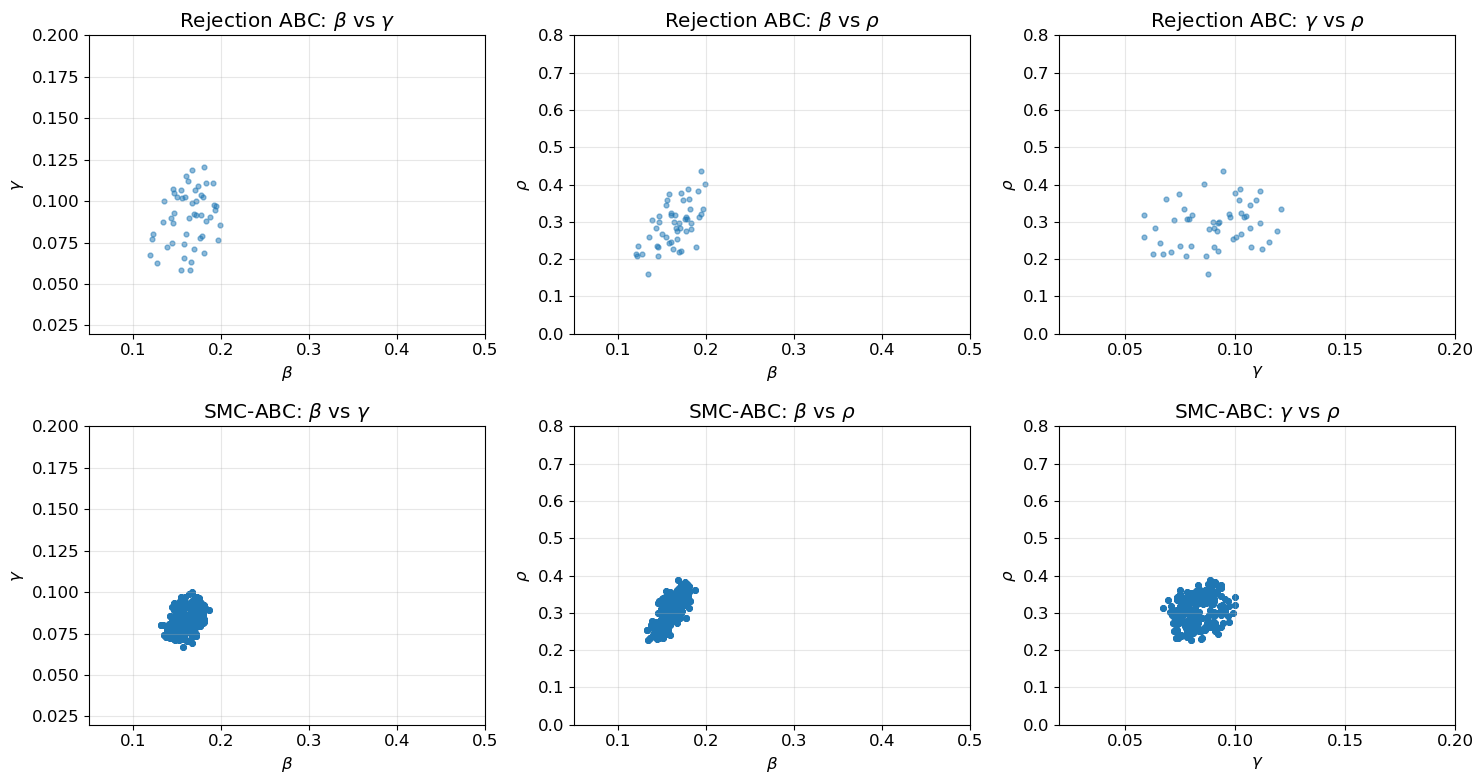

In [12]:
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.0, 0.80)]

def compare_pairwise_scatter(samples1, samples2, title1="Rejection ABC", title2="SMC-ABC"):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    pairs = [(0, 1), (0, 2), (1, 2)]

    for col, (i, j) in enumerate(pairs):
        # Top row
        axes[0, col].scatter(samples1[:, i], samples1[:, j], alpha=0.5, s=12)
        axes[0, col].set_xlabel(PARAM_NAMES[i])
        axes[0, col].set_ylabel(PARAM_NAMES[j])
        axes[0, col].set_title(f"{title1}: {PARAM_NAMES[i]} vs {PARAM_NAMES[j]}")
        axes[0, col].set_xlim(PRIOR_BOUNDS[i])
        axes[0, col].set_ylim(PRIOR_BOUNDS[j])

        # Bottom row
        axes[1, col].scatter(samples2[:, i], samples2[:, j], alpha=0.5, s=12)
        axes[1, col].set_xlabel(PARAM_NAMES[i])
        axes[1, col].set_ylabel(PARAM_NAMES[j])
        axes[1, col].set_title(f"{title2}: {PARAM_NAMES[i]} vs {PARAM_NAMES[j]}")
        axes[1, col].set_xlim(PRIOR_BOUNDS[i])
        axes[1, col].set_ylim(PRIOR_BOUNDS[j])

    plt.tight_layout()
    plt.show()

compare_pairwise_scatter(rej_posterior, smc_posterior)

## 13. Create the pairwise-correlation comparison table

This cell builds a table of absolute posterior correlations for each parameter pair and identifies which method shows weaker posterior dependence.


In [13]:
def correlation_table(samples, model_name=None):
    corr = np.corrcoef(samples.T)
    df = pd.DataFrame(
        corr,
        index=["beta", "gamma", "rho"],
        columns=["beta", "gamma", "rho"]
    )
    if model_name is not None:
        print(f"\n{model_name} correlation matrix:")
        print(df.round(3))
    return df

rej_corr = correlation_table(rej_posterior, "Rejection ABC")
smc_corr = correlation_table(smc_posterior, "SMC-ABC")


Rejection ABC correlation matrix:
        beta  gamma    rho
beta   1.000  0.265  0.599
gamma  0.265  1.000  0.217
rho    0.599  0.217  1.000

SMC-ABC correlation matrix:
        beta  gamma    rho
beta   1.000  0.335  0.712
gamma  0.335  1.000  0.246
rho    0.712  0.246  1.000


In [14]:
comparison_corr = pd.DataFrame({
    "Pair": ["beta-gamma", "beta-rho", "gamma-rho"],
    "Rejection ABC |corr|": [
        abs(rej_corr.loc["beta", "gamma"]),
        abs(rej_corr.loc["beta", "rho"]),
        abs(rej_corr.loc["gamma", "rho"]),
    ],
    "SMC-ABC |corr|": [
        abs(smc_corr.loc["beta", "gamma"]),
        abs(smc_corr.loc["beta", "rho"]),
        abs(smc_corr.loc["gamma", "rho"]),
    ]
})

comparison_corr["Better model"] = np.where(
    comparison_corr["SMC-ABC |corr|"] < comparison_corr["Rejection ABC |corr|"],
    "SMC-ABC",
    "Rejection ABC"
)

comparison_corr.round(3)

,Pair,Rejection ABC |corr|,SMC-ABC |corr|,Better model
0,beta-gamma,0.265,0.335,Rejection ABC
1,beta-rho,0.599,0.712,Rejection ABC
2,gamma-rho,0.217,0.246,Rejection ABC
